In [ ]:
#controls analysis; muscimol

In [1]:
%pip install -U npc_lims

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import datetime
import zoneinfo

import npc_lims
from npc_sessions import DynamicRoutingSession
from dynamic_routing_analysis import data_utils, spike_utils

import npc_sessions

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
#read in excel spreadsheet and conglomerate d primes across muscimol and good devs and compare

"Z:\DynamicRoutingTask\DynamicRoutingTraining.xlsx"

"Z:\DynamicRoutingTask\DynamicRoutingTrainingNSB.xlsx"

In [1]:
import pandas as pd

# Read in the Excel spreadsheets
training_df = pd.read_excel(r"Z:\DynamicRoutingTask\DynamicRoutingTraining.xlsx")
training_nsb_df = pd.read_excel(r"Z:\DynamicRoutingTask\DynamicRoutingTrainingNSB.xlsx")

# Preview the data (optional)
print(training_df.head())
print(training_nsb_df.head())

   mouse id status   purpose  alive genotype     sex  birthdate    whc    dhc  \
0    614910   dead  behavior  False  C57BL6J    male 2021-12-20  False  False   
1    615634   dead  behavior  False  C57BL6J    male 2021-12-28  False  False   
2    615635   dead  behavior  False  C57BL6J    male 2021-12-28  False  False   
3    615636   dead  behavior  False  C57BL6J  female 2021-12-28  False  False   
4    616266   dead  behavior  False  C57BL6J    male 2022-01-02  False  False   

   implant  cannula  cannula loc virus virus loc  regimen timeouts trainer  \
0      NaN    False          NaN   NaN       NaN        1    False     Sam   
1      NaN    False          NaN   NaN       NaN        1     True     Sam   
2      NaN    False          NaN   NaN       NaN        1    False  Jackie   
3      NaN    False          NaN   NaN       NaN        1     True  Jackie   
4      NaN    False          NaN   NaN       NaN        1    False     Sam   

  next task version  
0              dead  


In [ ]:
session_ids = ['774470_2025-07-29','774470_2025-07-30','782106_2025-07-07','782106_2025-07-14','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-19','767405_2025-05-20', '767405_2025-05-28', '767405_2025-05-29','739828_2025-02-10','739828_2025-02-11','739828_2025-02-17', '739828_2025-02-18','774916_2025-03-24', '774916_2025-03-25', '774916_2025-03-31', '774916_2025-04-01', '772657_2025-02-24', '772657_2025-02-25', '772657_2025-03-03', '772657_2025-03-04']
no_saline_orb_controls = ['774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31',]
saline_controls_orb = ['774916_2025-03-24','774916_2025-03-31', '772657_2025-03-03', '772657_2025-02-24', '739828_2025-02-10', '739828_2025-02-17',  ]
saline_controls_all = ['780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31','780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24','772657_2025-03-06','772657_2025-03-03','750877_2025-02-27','750877_2025-02-25', '772657_2025-02-24','750877_2025-02-24','739828_2025-02-20','739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10', '715706_2024-06-26','703881_2024-05-07','703881_2024-05-10','708020_2024-05-13','708020_2024-05-15','712141_2024-06-06','712141_2024-06-11','712141_2024-06-12','712141_2024-06-26']

In [2]:
# Find rows in the spreadsheets that match the session IDs in saline_controls_all

# Combine both spreadsheets
all_training = pd.concat([training_df, training_nsb_df], ignore_index=True)

# Make sure the session_id column exists and is string type
all_training['session_id'] = all_training['session_id'].astype(str)

# List of session IDs to find
saline_controls_all = [
    '780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31',
    '780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24','772657_2025-03-06','772657_2025-03-03',
    '750877_2025-02-27','750877_2025-02-25', '772657_2025-02-24','750877_2025-02-24','739828_2025-02-20',
    '739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10', '715706_2024-06-26','703881_2024-05-07',
    '703881_2024-05-10','708020_2024-05-13','708020_2024-05-15','712141_2024-06-06','712141_2024-06-11',
    '712141_2024-06-12','712141_2024-06-26'
]

# Filter for matching session IDs
saline_controls_df = all_training[all_training['session_id'].isin(saline_controls_all)]

# Show the found sessions
print(saline_controls_df[['session_id']])

KeyError: 'session_id'

In [5]:
import pandas as pd

def find_mouse_sheets(excel_path, session_ids):
    xl = pd.ExcelFile(excel_path)
    found_sheets = set()
    for session_id in session_ids:
        mouse_id = session_id[:6]  # first 6 digits
        for sheet in xl.sheet_names:
            if mouse_id in str(sheet):
                found_sheets.add(sheet)
    # Print column names for each found sheet
    for sheet in found_sheets:
        df = xl.parse(sheet)
        print(f"Sheet: {sheet} | Columns: {list(df.columns)}")


# Example usage:
saline_controls_all = [
    '780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31',
    '780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24','772657_2025-03-06','772657_2025-03-03',
    '750877_2025-02-27','750877_2025-02-25', '772657_2025-02-24','750877_2025-02-24','739828_2025-02-20',
    '739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10', '715706_2024-06-26','703881_2024-05-07',
    '703881_2024-05-10','708020_2024-05-13','708020_2024-05-15','712141_2024-06-06','712141_2024-06-11',
    '712141_2024-06-12','712141_2024-06-26'
]

# Find sheets in the first file
sheets1 = find_mouse_sheets(r"Z:\DynamicRoutingTask\DynamicRoutingTraining.xlsx", saline_controls_all)
print("Sheets in DynamicRoutingTraining.xlsx:", sheets1)

# Find sheets in the second file
sheets2 = find_mouse_sheets(r"Z:\DynamicRoutingTask\DynamicRoutingTrainingNSB.xlsx", saline_controls_all)
print("Sheets in DynamicRoutingTrainingNSB.xlsx:", sheets2)

# To load a sheet:
# df = pd.read_excel(r"Z:\DynamicRoutingTask\DynamicRoutingTraining.xlsx", sheet_name=sheets1[0])
# print(df.head())

Sheet: 774916 | Columns: ['start time', 'rig name', 'task version', 'hits', "d' same modality", "d' other modality go stim", 'quiescent violations', 'pass', 'ignore', 'hab', 'ephys', 'muscimol']
Sheet: 750877 | Columns: ['start time', 'rig name', 'task version', 'hits', "d' same modality", "d' other modality go stim", 'quiescent violations', 'pass', 'ignore', 'hab', 'ephys', 'muscimol']
Sheet: 739828 | Columns: ['start time', 'rig name', 'task version', 'hits', "d' same modality", "d' other modality go stim", 'quiescent violations', 'pass', 'ignore', 'hab', 'ephys', 'muscimol']
Sheets in DynamicRoutingTraining.xlsx: None
Sheet: 772657 | Columns: ['start time', 'rig name', 'computer name', 'task version', 'hits', "d' same modality", "d' other modality go stim", 'quiescent violations', 'ignore', 'hab', 'ephys', 'muscimol']
Sheet: 708020 | Columns: ['start time', 'rig name', 'computer name', 'task version', 'hits', "d' same modality", "d' other modality go stim", 'quiescent violations', '

In [50]:
import pandas as pd

saline_controls_all = [
    '780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31',
    '780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24','772657_2025-03-06','772657_2025-03-03',
    '750877_2025-02-27','750877_2025-02-25', '772657_2025-02-24','750877_2025-02-24','739828_2025-02-20',
    '739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10', '715706_2024-06-26','703881_2024-05-07',
    '708020_2024-05-13','708020_2024-05-15','712141_2024-06-06','712141_2024-06-11',
    '712141_2024-06-12','712141_2024-06-26'
]

def find_matching_rows_by_mouse_and_date(excel_path, session_ids):
    xl = pd.ExcelFile(excel_path)
    print("Sheet names:", xl.sheet_names)  # Debug: print all sheet names
    found_rows = []
    for session_id in session_ids:
        mouse_id = session_id[:6]
        date_str = session_id.split('_')[1]  # e.g. '2025-04-10'
        # Try to match sheet name containing mouse_id as substring
        matched_sheets = [sheet for sheet in xl.sheet_names if mouse_id in str(sheet)]
        print(f"Looking for mouse_id: {mouse_id}, date: {date_str} | Matched sheets: {matched_sheets}")
        for sheet in matched_sheets:
            df = xl.parse(sheet)
            if 'start time' in df.columns:
                date_only = df['start time'].astype(str).str[:10]
                match = df[date_only == date_str]
                print(f"  Sheet {sheet}: found {len(match)} rows for date {date_str}")
                if not match.empty:
                    found_rows.append(match)
            else:
                print(f"  Sheet {sheet} has no 'start time' column")
    if found_rows:
        return pd.concat(found_rows, ignore_index=True)
    else:
        print("No matches found.")
        return pd.DataFrame()

df1 = find_matching_rows_by_mouse_and_date(r"Z:\\DynamicRoutingTask\\DynamicRoutingTraining.xlsx", saline_controls_all)
df2 = find_matching_rows_by_mouse_and_date(r"Z:\\DynamicRoutingTask\\DynamicRoutingTrainingNSB.xlsx", saline_controls_all)
all_found = pd.concat([df1, df2], ignore_index=True)

print(all_found)

Sheet names: ['all mice', '795555', '798632', '782108', '807742', '800419', '793282', '805140', '800414', '801857', '810237', '803904', '812802', '815141', '805752', '817203', 'dead', '614910', '615634', '615635', '615636', '616266', '616270', '621898', '621899', '621900', '621903', '621904', '624731', '625918', '625919', '625917', '625920', '626791', '627688', '627690', '631862', '631865', '631863', '631866', '631864', '631867', '636766', '636761', '638573', '638574', '638575', '638576', '638577', '638578', '639249', '644860', '643279', '643280', '644861', '644864', '644866', '644867', '644862', '649943', '648623', '653493', '653481', '656054', '656726', '659250', '659492', '663031', '666024', '668758', '673557', '673558', '658096', '676910', '670243', '664851', '664566', '670242', '671438', '674723', '676909', '682892', '718642', '726088', '718283', '716718', '733888', '733780', '728917', '747818', '747550', '733891', '737403', '750091', '741137', '739833', '751595', '744740', '74755

In [51]:
import numpy as np

# Suppose you have a list of lists, where each inner list is the d' same modality for a session (length 6)
# Example: dprime_same_modal = [[1,2,3,4,5,6], [2,3,4,5,6,7], ...]  # 25 lists, each of length 6

# Replace this with your actual data extraction from all_found
dprime_same_modal = all_found["d' same modality"].tolist()  # Each entry should be a list of 6 numbers

# # Convert to numpy array for easy averaging
dprime_same_modal_arr = np.array(dprime_same_modal)

print(dprime_same_modal_arr)

# print("Average d' same modality across all sessions:", average_dprime_same_modal)

['[0.97 1.56 2.23 3.   3.56 1.28]' '[ 3.6   1.01  3.45  1.47  3.56 -0.18]'
 '[2.66 3.92 3.   3.6  2.3  3.92]' '[0.35 3.24 2.3  3.18 2.06 2.35]'
 '[3.56 3.6  2.72 3.6  3.18 3.83]' '[3.08 3.92 3.53 3.92 2.59 3.94]'
 '[2.94 3.17 2.56 3.24 3.48 3.92]' '[2.35 3.9  3.58 3.6  3.2  3.9 ]'
 '[3.53 3.9  2.44 3.92 3.19 3.08]' '[3.58 3.85 2.87 3.51 3.88 3.94]'
 '[3.53 2.76 2.94 2.63 3.92 2.93]' '[3.87 2.14 2.35 0.37 1.57 1.41]'
 '[3.9  1.63 3.83 2.46 3.58 1.87]' '[3.92 3.92 3.94 1.98 3.92 2.48]'
 '[2.14 3.19 1.82 3.58 1.62 2.93]' '[1.12 2.9  0.61 3.29 1.06 3.88]'
 '[3.   1.32 3.92 1.81 3.63 1.44]' '[0.29 3.21 0.63 3.55 1.55 3.92]'
 '[0.3  1.68 1.13 2.74 0.59 3.58]' '[2.68 0.78 3.16 1.63 3.85 0.78]'
 '[3.56 0.68 3.83 1.73 3.5  2.08]' '[3.88 3.16 3.53 2.9  3.6  3.56]'
 '[2.63 3.45 1.2  2.03 2.34 3.21]' '[1.16 3.   0.   3.88 0.7  2.94]'
 '[1.6  3.   0.92 3.94 1.16 3.9 ]']


In [52]:
import numpy as np

# If dprime_same_modal_arr is a numpy array of strings, convert each string to a numeric numpy array
numeric_arrays = []
for row in dprime_same_modal_arr:
    # Remove brackets if present and convert string to float array
    arr = np.fromstring(row.replace('[','').replace(']',''), sep=' ')
    numeric_arrays.append(arr)

# Stack into a 2D numpy array (sessions x 6)
dprime_same_modal_numeric = np.vstack(numeric_arrays)

print(dprime_same_modal_numeric)

[[ 0.97  1.56  2.23  3.    3.56  1.28]
 [ 3.6   1.01  3.45  1.47  3.56 -0.18]
 [ 2.66  3.92  3.    3.6   2.3   3.92]
 [ 0.35  3.24  2.3   3.18  2.06  2.35]
 [ 3.56  3.6   2.72  3.6   3.18  3.83]
 [ 3.08  3.92  3.53  3.92  2.59  3.94]
 [ 2.94  3.17  2.56  3.24  3.48  3.92]
 [ 2.35  3.9   3.58  3.6   3.2   3.9 ]
 [ 3.53  3.9   2.44  3.92  3.19  3.08]
 [ 3.58  3.85  2.87  3.51  3.88  3.94]
 [ 3.53  2.76  2.94  2.63  3.92  2.93]
 [ 3.87  2.14  2.35  0.37  1.57  1.41]
 [ 3.9   1.63  3.83  2.46  3.58  1.87]
 [ 3.92  3.92  3.94  1.98  3.92  2.48]
 [ 2.14  3.19  1.82  3.58  1.62  2.93]
 [ 1.12  2.9   0.61  3.29  1.06  3.88]
 [ 3.    1.32  3.92  1.81  3.63  1.44]
 [ 0.29  3.21  0.63  3.55  1.55  3.92]
 [ 0.3   1.68  1.13  2.74  0.59  3.58]
 [ 2.68  0.78  3.16  1.63  3.85  0.78]
 [ 3.56  0.68  3.83  1.73  3.5   2.08]
 [ 3.88  3.16  3.53  2.9   3.6   3.56]
 [ 2.63  3.45  1.2   2.03  2.34  3.21]
 [ 1.16  3.    0.    3.88  0.7   2.94]
 [ 1.6   3.    0.92  3.94  1.16  3.9 ]]


In [53]:
import pandas as pd
import numpy as np

# dprime_same_modal_numeric is your (sessions x 6) numpy array
# Compute the mean for each column (ignore NaN)
averages = np.nanmean(dprime_same_modal_numeric, axis=0)

# Create a DataFrame with one row and 6 columns
df_avg = pd.DataFrame([averages], columns=[f'col_{i+1}' for i in range(dprime_same_modal_numeric.shape[1])])

print(df_avg)

   col_1   col_2   col_3   col_4   col_5   col_6
0  2.568  2.7556  2.4996  2.8624  2.7036  2.8356


(-1.0, 3.0)

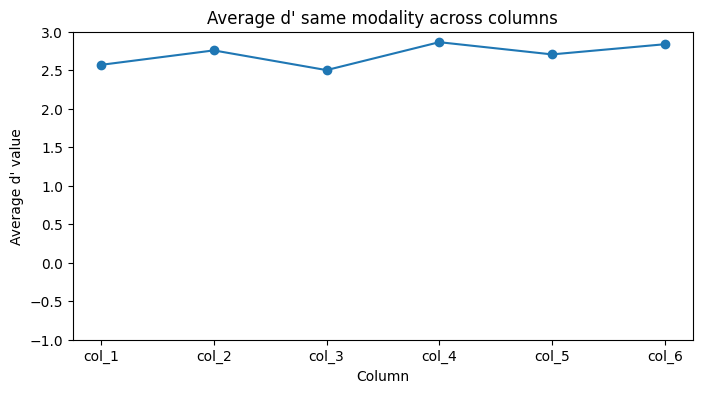

In [54]:
import matplotlib.pyplot as plt

# Plot the averages as a line plot
plt.figure(figsize=(8, 4))
plt.plot(df_avg.columns, df_avg.iloc[0], marker='o')
plt.xlabel("Column")
plt.ylabel("Average d' value")
plt.title("Average d' same modality across columns")
plt.ylim(-1, 3)  # Set y-axis from -1 to

## saline injection controls

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_16756\385948139.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(unique_sessions))


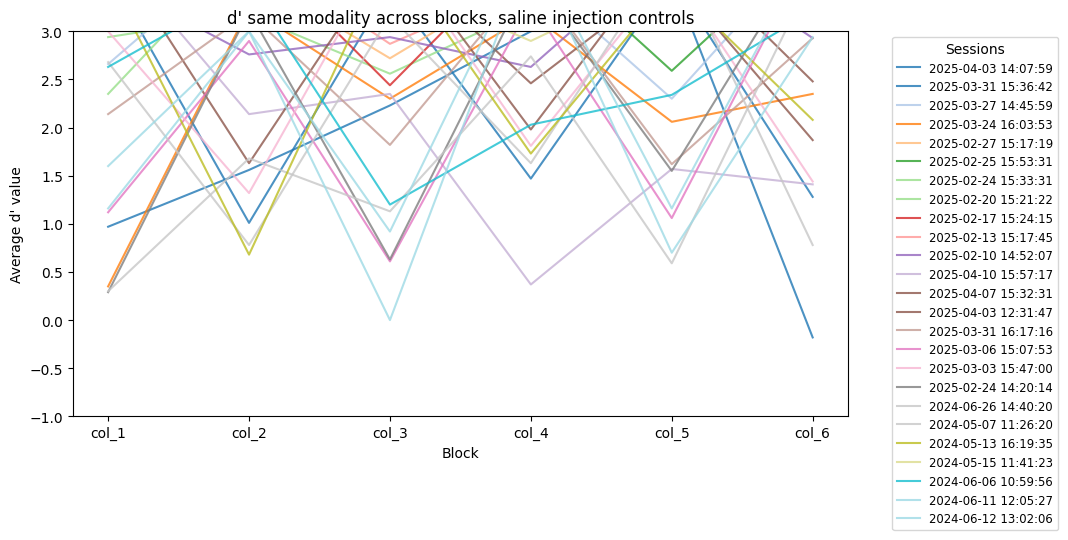

In [64]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Get session_ids (should match dprime_same_modal_numeric order)
session_ids = all_found['start time'].tolist()

# Assign a unique color to each session
unique_sessions = list(dict.fromkeys(session_ids))  # preserve order, remove duplicates
colors = cm.get_cmap('tab20', len(unique_sessions))

plt.figure(figsize=(10, 5))

# Plot each session as a colored line, label with mouseID and date
for i, row in enumerate(dprime_same_modal_numeric):
    session = session_ids[i]
    color_idx = unique_sessions.index(session)
    label = session  # session_id is mouseID_date
    plt.plot(df_avg.columns, row, color=colors(color_idx), alpha=0.8, linewidth=1.5, label=label)

# Plot the average as a bold black line
# plt.plot(df_avg.columns, df_avg.iloc[0], marker='o', color='black', linewidth=3, label="Average")

plt.xlabel("Block")
plt.ylabel("Average d' value")
plt.title("d' same modality across blocks, saline injection controls")
plt.ylim(-1, 3)

# Show legend outside plot if too many sessions
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title="Sessions")

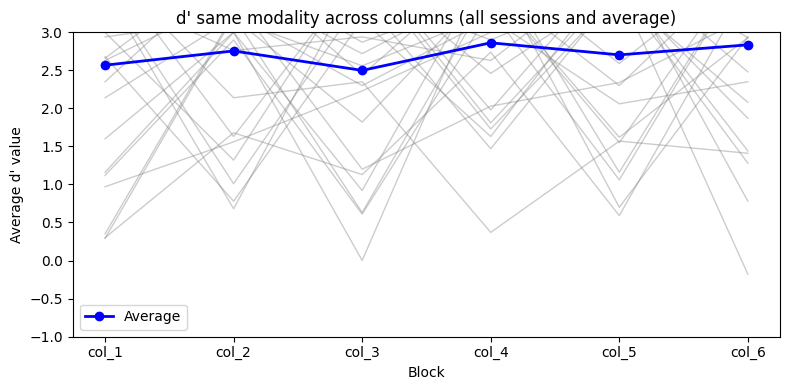

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# Plot each session as a faint gray line
for row in dprime_same_modal_numeric:
    plt.plot(df_avg.columns, row, color='gray', alpha=0.4, linewidth=1)

# Plot the average as a bold line
plt.plot(df_avg.columns, df_avg.iloc[0], marker='o', color='blue', linewidth=2, label="Average")

plt.xlabel("Block")
plt.ylabel("Average d' value")
plt.title("d' same modality across columns (all sessions and average)")
plt.ylim(-1, 3)
plt.legend()
plt.tight_layout()

In [ ]:
#plot d' same modal (avg all ctrls; pink muscimol, blue devs)
#plot d' other modal (avg all ctrls; pink muscimol, blue devs)

# make a scatter plot with a cluster of dev ctrls and a cluster of muscimol for either d's or RRs



## no saline orb controls

In [40]:
no_saline_orb_controls = ['774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31',]

In [42]:
df1 = find_matching_rows_by_mouse_and_date(r"Z:\\DynamicRoutingTask\\DynamicRoutingTraining.xlsx", no_saline_orb_controls)
df2 = find_matching_rows_by_mouse_and_date(r"Z:\\DynamicRoutingTask\\DynamicRoutingTrainingNSB.xlsx", no_saline_orb_controls)
no_saline_orb = pd.concat([df1, df2], ignore_index=True)

print(no_saline_orb)

Sheet names: ['all mice', '795555', '798632', '782108', '807742', '800419', '793282', '805140', '800414', '801857', '810237', '803904', '812802', '815141', '805752', '817203', 'dead', '614910', '615634', '615635', '615636', '616266', '616270', '621898', '621899', '621900', '621903', '621904', '624731', '625918', '625919', '625917', '625920', '626791', '627688', '627690', '631862', '631865', '631863', '631866', '631864', '631867', '636766', '636761', '638573', '638574', '638575', '638576', '638577', '638578', '639249', '644860', '643279', '643280', '644861', '644864', '644866', '644867', '644862', '649943', '648623', '653493', '653481', '656054', '656726', '659250', '659492', '663031', '666024', '668758', '673557', '673558', '658096', '676910', '670243', '664851', '664566', '670242', '671438', '674723', '676909', '682892', '718642', '726088', '718283', '716718', '733888', '733780', '728917', '747818', '747550', '733891', '737403', '750091', '741137', '739833', '751595', '744740', '74755

In [44]:
dprime_same_modal_no_saline_orb = no_saline_orb["d' same modality"].tolist()  # Each entry should be a list of 6 numbers

# # Convert to numpy array for easy averaging
dprime_same_modal_arr_no_saline_orb = np.array(dprime_same_modal_no_saline_orb)

print(dprime_same_modal_arr_no_saline_orb)

['[1.22 2.18 2.74 2.96 2.19 3.11]' '[3.83 1.71 3.87 2.11 3.94 1.69]'
 '[0.35 3.24 2.3  3.18 2.06 2.35]' '[ 3.6   1.01  3.45  1.47  3.56 -0.18]'
 '[0.34 2.85 1.37 3.88 0.93 2.5 ]' '[3.92 3.2  3.85 2.48 3.16 2.18]'
 '[2.48 3.88 3.6  1.48 3.45 3.21]' '[0.29 3.21 0.63 3.55 1.55 3.92]'
 '[3.   1.32 3.92 1.81 3.63 1.44]']


In [45]:
numeric_arrays = []
for row in dprime_same_modal_arr_no_saline_orb:
    # Remove brackets if present and convert string to float array
    arr = np.fromstring(row.replace('[','').replace(']',''), sep=' ')
    numeric_arrays.append(arr)

# Stack into a 2D numpy array (sessions x 6)
dprime_same_modal_numeric_no_saline_orb = np.vstack(numeric_arrays)

print(dprime_same_modal_numeric_no_saline_orb)

[[ 1.22  2.18  2.74  2.96  2.19  3.11]
 [ 3.83  1.71  3.87  2.11  3.94  1.69]
 [ 0.35  3.24  2.3   3.18  2.06  2.35]
 [ 3.6   1.01  3.45  1.47  3.56 -0.18]
 [ 0.34  2.85  1.37  3.88  0.93  2.5 ]
 [ 3.92  3.2   3.85  2.48  3.16  2.18]
 [ 2.48  3.88  3.6   1.48  3.45  3.21]
 [ 0.29  3.21  0.63  3.55  1.55  3.92]
 [ 3.    1.32  3.92  1.81  3.63  1.44]]


In [46]:
averages_no_saline_orb = np.nanmean(dprime_same_modal_numeric_no_saline_orb, axis=0)

# Create a DataFrame with one row and 6 columns
df_avg_no_saline_orb = pd.DataFrame([averages_no_saline_orb], columns=[f'col_{i+1}' for i in range(dprime_same_modal_numeric_no_saline_orb.shape[1])])

print(df_avg_no_saline_orb)

      col_1     col_2     col_3     col_4     col_5     col_6
0  2.114444  2.511111  2.858889  2.546667  2.718889  2.246667


(-1.0, 3.0)

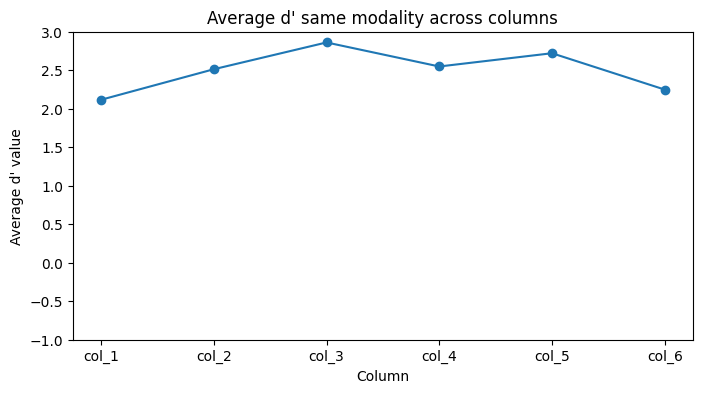

In [47]:
import matplotlib.pyplot as plt

# Plot the averages as a line plot
plt.figure(figsize=(8, 4))
plt.plot(df_avg_no_saline_orb.columns, df_avg_no_saline_orb.iloc[0], marker='o')
plt.xlabel("Column")
plt.ylabel("Average d' value")
plt.title("Average d' same modality across columns")
plt.ylim(-1, 3)

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_16756\3848635848.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(unique_sessions))


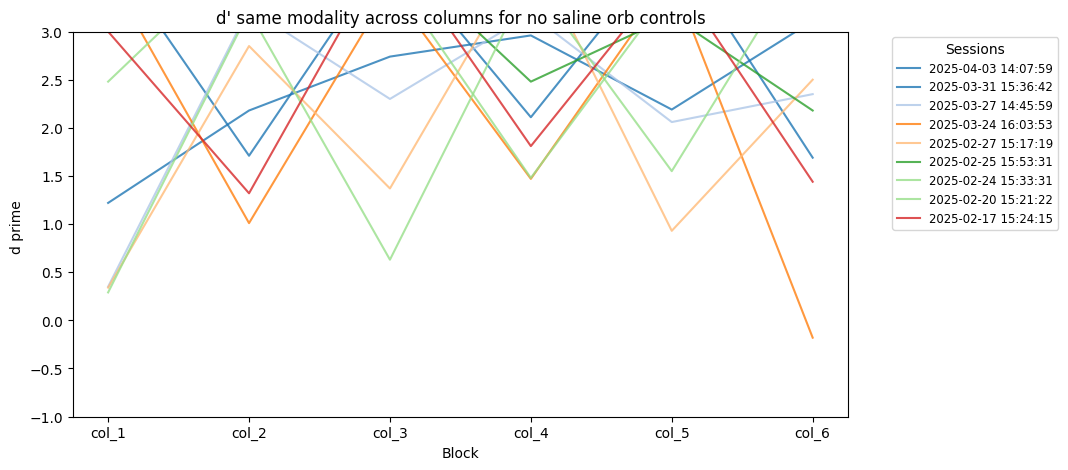

In [63]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Get session_ids (should match dprime_same_modal_numeric order)
session_ids = all_found['start time'].tolist()

# Assign a unique color to each session
unique_sessions = list(dict.fromkeys(session_ids))  # preserve order, remove duplicates
colors = cm.get_cmap('tab20', len(unique_sessions))

plt.figure(figsize=(10, 5))

# Plot each session as a colored line, label with mouseID and date
for i, row in enumerate(dprime_same_modal_numeric_no_saline_orb):
    session = session_ids[i]
    color_idx = unique_sessions.index(session)
    label = session  # session_id is mouseID_date
    plt.plot(df_avg_no_saline_orb.columns, row, color=colors(color_idx), alpha=0.8, linewidth=1.5, label=label)

# Plot the average as a bold black line
# plt.plot(df_avg_no_saline_orb.columns, df_avg.iloc[0], marker='o', color='black', linewidth=3, label="Average")

plt.xlabel("Block")
plt.ylabel("d prime ")
plt.title("d' same modality across columns for no saline orb controls")
plt.ylim(-1, 3)

# Show legend outside plot if too many sessions
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title="Sessions")

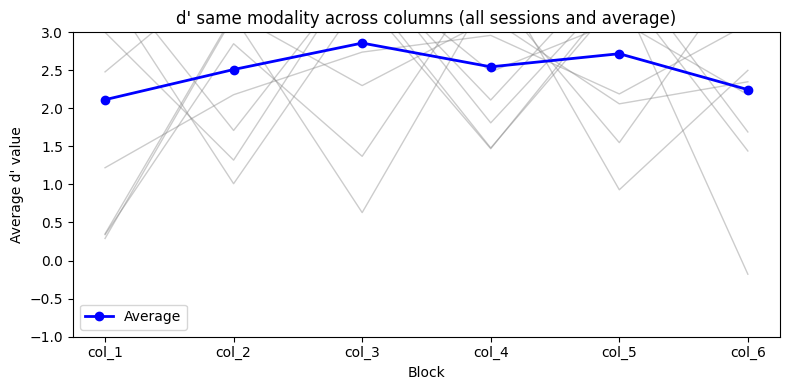

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# Plot each session as a faint gray line
for row in dprime_same_modal_numeric_no_saline_orb:
    plt.plot(df_avg_no_saline_orb.columns, row, color='gray', alpha=0.4, linewidth=1)

# Plot the average as a bold line
plt.plot(df_avg_no_saline_orb.columns, df_avg_no_saline_orb.iloc[0], marker='o', color='blue', linewidth=2, label="Average")

plt.xlabel("Block")
plt.ylabel("Average d' value")
plt.title("d' same modality across columns (all sessions and average)")
plt.ylim(-1, 3)
plt.legend()
plt.tight_layout()

In [ ]:
#controls analysis

#start by making a datafram with your columns and data of interest. you can make a function that takes session_id and loops thru to return the trials information you want averaged and contactenated

#def(mouse, perturbation or control)
session_ids = ['774470_2025-07-29','774470_2025-07-30','782106_2025-07-07','782106_2025-07-14','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-19','767405_2025-05-20', '767405_2025-05-28', '767405_2025-05-29','739828_2025-02-10','739828_2025-02-11','739828_2025-02-17', '739828_2025-02-18','774916_2025-03-24', '774916_2025-03-25', '774916_2025-03-31', '774916_2025-04-01', '772657_2025-02-24', '772657_2025-02-25', '772657_2025-03-03', '772657_2025-03-04']
no_saline_orb_controls = ['774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31',]
saline_controls_orb = ['774916_2025-03-24','774916_2025-03-31', '772657_2025-03-03', '772657_2025-02-24', '739828_2025-02-10', '739828_2025-02-17',  ]
saline_controls_all = ['780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31','780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24','772657_2025-03-06','772657_2025-03-03','750877_2025-02-27','750877_2025-02-25', '772657_2025-02-24','750877_2025-02-24','739828_2025-02-20','739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10', '715706_2024-06-26','703881_2024-05-07','703881_2024-05-10','708020_2024-05-13','708020_2024-05-15','712141_2024-06-06','712141_2024-06-11','712141_2024-06-12','712141_2024-06-26']

dev_controls = [] #filter spreadsheet by d' > 1.5 for 3 blocks of each modality

for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    quiescent_violations=quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_orb.append(result)

# print(muscimol_data)
muscimol_df_orb = pd.DataFrame(muscimol_data_orb)
print(muscimol_df_orb)

In [ ]:
#make a scatter plot with a unity line. plot each paired control and perturbation session as a dot with the x axis indicating control dev and the y axis indicating control muscimol